**K.V.Kozenko, V.V.Gromyko, I.I.Beterov, I.I.Ryabtsev. We study the performance of amplitude-robust gates. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

C:\Users\Ilya Beterov\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Defining step for Levine-Pichler gate**

In [2]:
def phase_step(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    phase = ansatz_params[0]
    return phase*jnp.heaviside(t-duration/2,1)


**Comparing with other gate schemes. First, we plot the phase profile for Levine-Pichler and time-optimal gates**

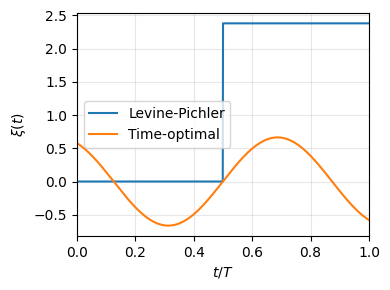

In [3]:
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
pulse_ansatz_1 = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const
)
initial_params1=(1,[-0.37736613*8.585308327286219],[2.38073847],[8.585308327286219])


pulse_ansatz_2 = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
initial_params2=(1, [0.03125944*7.626643597908442], [0.81977751, 0.66389043], [7.626643597908442])

duration = 1
num_points=1024
times = jnp.linspace(0, duration, num_points)
values1 = np.array(pulse_ansatz_1.evaluate_pulse_functions(times, initial_params1))
values2 = np.array(pulse_ansatz_2.evaluate_pulse_functions(times, initial_params2))

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(times, values1[1], label= 'Levine-Pichler')
ax.plot(times, values2[1], label= 'Time-optimal')
 
ax.set_xmargin(0)
ax.set_xlabel(r"$t /T$")
ylabel = r"$\xi(t)$"
ax.set_ylabel(ylabel)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig('Gate_phase_profiles.svg', format='svg')
plt.show()

**Plot phase profile for robust pulse**

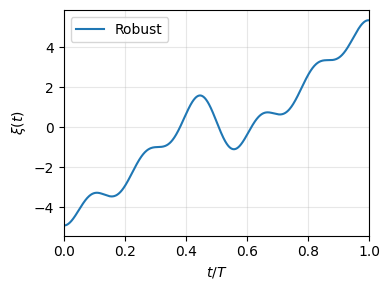

In [4]:
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
pulse_ansatz_3 = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
initial_params3 =   (1.0, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [17.550800323486328])
duration = 1
num_points=1024
times = jnp.linspace(0, duration, num_points)

values3 = np.array(pulse_ansatz_3.evaluate_pulse_functions(times, initial_params3))
fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(times, values3[1], label= 'Robust')
ax.set_xmargin(0)
ax.set_xlabel(r"$t /T$")
ylabel = r"$\xi(t)$"
ax.set_ylabel(ylabel)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig('Gate_phase_profiles_Robust.svg', format='svg')
plt.show()

**Re-define plot pulse with saving to file**

In [5]:
from typing import cast
def plot_pulse(
    pulse: PulseAnsatz,
    params: PulseParams,
    *,
    plot_detuning: bool = True,
    plot_phase: bool = True,
    plot_rabi: bool = True,
    subtract_phase_offset: bool = False,
    num_points: int = 1024,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    
    duration = params[0]

    times = jnp.linspace(0, duration, num_points)

    # Evaluated pulse
    selector = [plot_detuning, plot_phase, plot_rabi]

    values = np.array(pulse.evaluate_pulse_functions(times, params))
    if subtract_phase_offset:
        values[1] -= values[1][0]
    values = values[selector]

    labels = np.array(
        [
            r"$\Delta(t)$",
            r"$\xi(t)$",
            r"$\Omega(t)$",
        ]
    )[selector]

    ylabel = ", ".join(
        np.array(
            [
                r"$T\Delta $",
                r"$\xi$ [rad]",
                r"$T\Omega $",
            ]
        )[selector]
    )

    # Plot pulse
    owns_ax = ax is None

    if owns_ax:
        fig, ax = plt.subplots(figsize=(4, 3))
    else:
        assert ax is not None
        fig = cast(plt.Figure, ax.figure)

    for v, label in zip(values, labels):
        ax.plot(times, v, label=label)

    if owns_ax:
        ax.set_xmargin(0)
        ax.set_xlabel(r"$t/ T$")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
    plt.savefig('Pulse_plot.svg', format='svg')
    return fig, ax

***Testing plot***

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='$t/ T$', ylabel='$T\\Delta $, $\\xi$ [rad], $T\\Omega $'>)

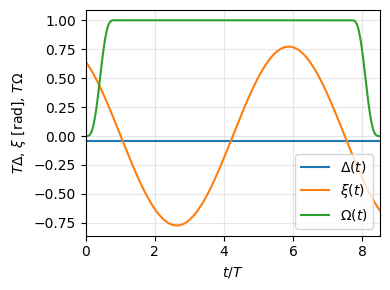

In [6]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
initial_params=(2.09722135*4.058348807763706, [-0.09393892/2.09722135 ], [0.73884332, 0.77225565], [1, 0.19713572])
plot_pulse(pulse_ansatz,initial_params)

In [7]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states).item()

1.0000000018113213

**Here we investigate robustness of different gate schemes to variation of Rabi frequencies**

**Calculating robustness to variation of Rabi frequency for Levine-Pichler gate**

In [7]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const)
FLevine=[]
d=8.585308327286219
optimized_params=(1, [-0.37736613*d], [2.38073847], [d])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn="Inf", decay=0.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[(1+Eps[i])*d]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevine.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevine

[0.007391949001934406,
 0.004816027858024263,
 0.0027597258832562366,
 0.001250244722890037,
 0.0003187791819686536,
 7.85302844974467e-09,
 0.00033147825126644825,
 0.0013528884729934187,
 0.0031052719935245054,
 0.005630095936919655,
 0.008968284081975808]

In [14]:
FLevine=[0.007391949001934406,
 0.004816027858024263,
 0.0027597258832562366,
 0.001250244722890037,
 0.0003187791819686536,
 7.85302844974467e-09,
 0.00033147825126644825,
 0.0013528884729934187,
 0.0031052719935245054,
 0.005630095936919655,
 0.008968284081975808]

***Calculating angle***

In [8]:
initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[1.0*d]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
np.angle(time_evolved_basis_states[0][0])

np.float64(2.3807531308346808)

**Calculating robustness for time-optimal gate**

In [9]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz  = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
d=7.6266
optimized_params =(1, [0.03126*d], [0.82, 0.664], [1*d])
FTO=[]
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn="Inf", decay=0.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTO.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FTO

[0.00805477112287678,
 0.005220225338425477,
 0.0029756622929946186,
 0.0013412394920145898,
 0.0003405367148824334,
 5.5350276473298266e-08,
 0.00034859752817983924,
 0.0014165256893975409,
 0.003234906602676779,
 0.005834546545042674,
 0.009244928917140571]

In [11]:
FTO=[0.00805477112287678,
 0.005220225338425477,
 0.0029756622929946186,
 0.0013412394920145898,
 0.0003405367148824334,
 5.5350276473298266e-08,
 0.00034859752817983924,
 0.0014165256893975409,
 0.003234906602676779,
 0.005834546545042674,
 0.009244928917140571]

**Calculating robustness to variation of Rabi frequency for robust gate**

In [11]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)

FRobust=[]
const_end_new_metrics_params = (1.0, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [17.550800323486328])
duration = 1
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn="Inf", decay=0.0)
for i in range(len(Eps)):
    initial_params=const_end_new_metrics_params[0],const_end_new_metrics_params[1],const_end_new_metrics_params[2],[17.550800323486328*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const,  initial_params)
    FRobust.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobust

[5.95636985423198e-06,
 2.2850109074878944e-06,
 1.3117308631516167e-06,
 1.8220427198123446e-06,
 2.8056166873069444e-06,
 3.494186915031783e-06,
 3.4385789219326668e-06,
 2.5909102610022217e-06,
 1.4007307507224454e-06,
 9.022272514647156e-07,
 2.796790185444209e-06]

In [12]:
FRobust=[5.95636985423198e-06,
 2.2850109074878944e-06,
 1.3117308631516167e-06,
 1.8220427198123446e-06,
 2.8056166873069444e-06,
 3.494186915031783e-06,
 3.4385789219326668e-06,
 2.5909102610022217e-06,
 1.4007307507224454e-06,
 9.022272514647156e-07,
 2.796790185444209e-06]

In [12]:
initial_params=const_end_new_metrics_params[0],const_end_new_metrics_params[1],const_end_new_metrics_params[2],[17.550800323486328]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const,  initial_params)
time_evolved_basis_states
np.angle(time_evolved_basis_states[0][0])

np.float64(-2.7807768190701156)

In [13]:
FCounter=[0.001087648629232607,
 0.0006998464993499542,
 0.00039665698296798,
 0.00017863597708012158,
 4.6290265686921295e-05,
 7.550189284888376e-08,
 4.039487898332972e-05,
 0.0001675964796730156,
 0.00038197226140856966,
 0.0006837563212298559,
 0.0010731234195280326]

**Comparing robustness to variation of Rabi frequency for three gate schemes**

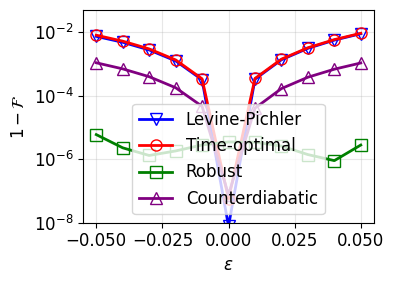

In [31]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(Eps, FLevine, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)
# Plot the second series
ax.plot(Eps, FTO, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Eps, FRobust, label='Robust', color='green', marker='s', mfc='none', markersize=8)

ax.plot(Eps, FCounter, label='Counterdiabatic', color='purple', marker='^', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-8,5e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('Robustness.svg', format='svg')
# Display the plot
plt.show()

`**Defining the class for individual addressing with infinite blockade strength**

In [20]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateInd:

    def __init__(self, s: float):
        self._s = s

 
    
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex),   jnp.array([1,0], dtype=complex),  jnp.array([1,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5],
                   [Omega* jnp.exp(1j * Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            s=self._s
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5*s],
                   [Omega* jnp.exp(1j * Xi)*s*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1r,r1,rr"""

            s=self._s
            return jnp.array(
                    [
                      [0, Omega*jnp.exp(-1j * Xi)*0.5, Omega*jnp.exp(-1j * Xi)*0.5*s], 
                      [Omega*jnp.exp(1j * Xi)*0.5, Delta, 0], 
                      [Omega* jnp.exp(1j * Xi)*0.5*s, 0,  Delta]
                    ]       
                )
        return hamiltonian1, hamiltonian2, hamiltonian3

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Calculating robustness to asymmetry of Rabi frequencies for amplitude-robust gate**

In [21]:
alpha=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)

FRobustAlpha=[]
d=19.16385937372734
const_end_new_metrics_params =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])

for i in range(len(Eps)):
    gate = CZGateInd(s=1+alpha[i])
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const,  const_end_new_metrics_params )
    FRobustAlpha.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobustAlpha

[0.00026883316007397795,
 0.00017239420287462615,
 9.8362036780264e-05,
 4.54945085172076e-05,
 1.3043240226995323e-05,
 7.291892006877632e-07,
 8.713212659383629e-06,
 3.75681362380087e-05,
 8.824734043999527e-05,
 0.00016205618744435935,
 0.0002606206910943376]

In [34]:
FRobustAlpha=[0.00026883316007397795,
 0.00017239420287462615,
 9.8362036780264e-05,
 4.54945085172076e-05,
 1.3043240226995323e-05,
 7.291892006877632e-07,
 8.713212659383629e-06,
 3.75681362380087e-05,
 8.824734043999527e-05,
 0.00016205618744435935,
 0.0002606206910943376]

**Calculating robustness to asymmetry of Rabi frequencies for Levine-Pichler gate**

In [22]:
alpha=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const)
FLevineAlpha=[]
d=8.585308327286219
optimized_params=(1, [-0.37736613*d], [2.38073847], [1*d])
for i in range(len(Eps)):
    gate = CZGateInd(s=1+alpha[i])
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz ,  optimized_params )
    FLevineAlpha.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevineAlpha

[0.0038972477901045854,
 0.0024756421353212543,
 0.0013819157573717877,
 0.0006094044986106883,
 0.00015116382991264832,
 9.221789110114287e-09,
 0.00014855533507662777,
 0.0005892542320177219,
 0.0013144311811683629,
 0.002316318186098454,
 0.0035870862162621364]

In [32]:
FLevineAlpha=[0.0038972477901045854,
 0.0024756421353212543,
 0.0013819157573717877,
 0.0006094044986106883,
 0.00015116382991264832,
 9.221789110114287e-09,
 0.00014855533507662777,
 0.0005892542320177219,
 0.0013144311811683629,
 0.002316318186098454,
 0.0035870862162621364]

In [23]:
alpha=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
optimized_params=(1, [0.03125944*7.626643597908442], [0.81977751, 0.66389043], [7.626643597908442])
FTOAlpha=[]
 
for i in range(len(Eps)):
    gate = CZGateInd(s=1+alpha[i])
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz ,  optimized_params )
    FTOAlpha.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FTOAlpha

[0.0050977240873062435,
 0.0032575454880249266,
 0.001829345505726554,
 0.0008116380315655869,
 0.00020257829490222257,
 -6.655809237088306e-10,
 0.00020144818077616478,
 0.000804221529762339,
 0.0018054006623392516,
 0.00320188527230858,
 0.004990425912740459]

In [33]:
FTOAlpha=[0.0050977240873062435,
 0.0032575454880249266,
 0.001829345505726554,
 0.0008116380315655869,
 0.00020257829490222257,
 -6.655809237088306e-10,
 0.00020144818077616478,
 0.000804221529762339,
 0.0018054006623392516,
 0.00320188527230858,
 0.004990425912740459]

***Class for counterdiabatic gate***

In [25]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateIndCounter:

    def __init__(self, s: float):
        self._s = s

 
    
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex),   jnp.array([1,0], dtype=complex),  jnp.array([1,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            return jnp.array(
                [
                   [0,(Omega-1j * Xi)*0.5],
                   [(Omega+1j * Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            s=self._s
            return jnp.array(
                [
                   [0,(Omega-1j * Xi)*0.5*s],
                   [(Omega+1j * Xi)*s*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1r,r1,rr"""

            s=self._s
            return jnp.array(
                    [
                      [0, (Omega-1j * Xi)*0.5, (Omega-1j * Xi)*0.5*s], 
                      [(Omega+1j * Xi)*0.5, Delta, 0], 
                      [(Omega+1j * Xi)*0.5*s, 0,  Delta]
                    ]       
                )
        return hamiltonian1, hamiltonian2, hamiltonian3

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

In [26]:
def double_sin(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    return amplitude1*jnp.sin(2*jnp.pi*(t-t1)/duration)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.sin(2*jnp.pi*(t-t2)/duration)*jnp.heaviside(t-duration/2,1)



def double_exp(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    return amplitude1*jnp.exp(-((t-t1)/wt)**4)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.exp(-((t-t2)/wt)**4)*jnp.heaviside(t-duration/2,1)


def counterdia(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    if len(ansatz_params)>2:
        RabiArray = ansatz_params[0::2]
        Rabi1=RabiArray[0]
        Rabi2=RabiArray[1]
    else: 
        Rabi1=ansatz_params[0]
        Rabi2=Rabi1

    if len(ansatz_params)>3:    
        detuningArray= ansatz_params[1::2]
        detuning1=detuningArray[0]
        detuning2=detuningArray[1]
    else:
        detuning1=ansatz_params[1]
        detuning2=detuning1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    
    
    def Delta(t,t_c=0.0,detuning=detuning1):
        return detuning*(jnp.sin(2*jnp.pi*(t-t_c)/duration))
                         
    def OmegaRe(t,t_c=0.0,Rabi=Rabi1):
        return Rabi*(jnp.exp(-((t-t_c)/wt)**4))
                     
    def Derive(t,t_c=0.0,Rabi=Rabi1,detuning=detuning1):
        return (Delta(t,t_c,detuning)*Rabi*4*((t-t_c)**3)*jnp.exp(-((t-t_c)/wt)**4)/(wt**4)+OmegaRe(t,t_c,Rabi)*detuning*2*jnp.pi*jnp.cos(2*jnp.pi*(t-t_c)/duration)/duration)/(OmegaRe(t,t_c,Rabi1)**2+Delta(t,t_c,detuning1)**2)
                     
           
    return jnp.heaviside(duration/2-t,0)*Derive(t,t1,Rabi1,detuning1)+jnp.heaviside(t-duration/2,1)*Derive(t,t2,Rabi2,detuning2)    

In [27]:
pulse_ansatz_counter = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params_counter=(1,[1.0*2*jnp.pi], [2.003*2*jnp.pi,1.0*2*jnp.pi], [2.003*2*jnp.pi])

In [28]:
gate_counter = CZGateIndCounter(s=1)
time_evolved_basis_states = ro.simulation.evolve(gate_counter, pulse_ansatz_counter, initial_params_counter)
gate_counter.process_fidelity(time_evolved_basis_states)

Array(0.99999993, dtype=float64)

In [29]:
alpha=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_counter = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params_counter=(1,[1.0*2*jnp.pi], [2.003*2*jnp.pi,1.0*2*jnp.pi], [2.003*2*jnp.pi])
FCounterAlpha=[]
 
for i in range(len(alpha)):
    gate = CZGateIndCounter(s=1+alpha[i])
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_counter ,  initial_params_counter )
    FCounterAlpha.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FCounterAlpha

[0.0021777239962467165,
 0.0013727441415470887,
 0.0007615543848094042,
 0.0003349218792128017,
 8.393855517419002e-05,
 7.243796251721335e-08,
 7.52199388122099e-05,
 0.00030175338363791493,
 0.0006725678958827697,
 0.0011811231751852613,
 0.0018214836458771977]

**Plot comparison of robustness to asymmetry**

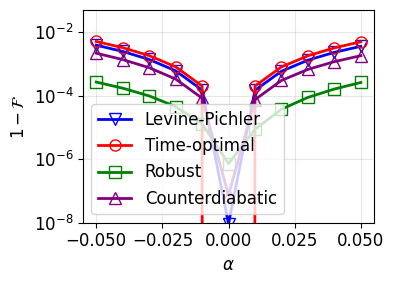

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(alpha, FLevineAlpha, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)
# Plot the second series
ax.plot(alpha, FTOAlpha, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(alpha, FRobustAlpha, label='Robust', color='green', marker='s', mfc='none', markersize=8)
# Plot the third series
ax.plot(alpha, FCounterAlpha, label='Counterdiabatic', color='purple', marker='^', mfc='none', markersize=8)

# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\alpha $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-8,5e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessAlpha.svg', format='svg')
# Display the plot
plt.show()

**Defining pulse profiles with gradient of Rabi frequency**

**Defining linear profile of Rabi frequency**

In [36]:
def lin_profile(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    Rabi0 = ansatz_params[0]
    Rabi1 = ansatz_params[1]
    return Rabi0+(Rabi1-Rabi0)*t/duration

**Re-defining amplitude-robust gate with gradient of Rabi frequency**

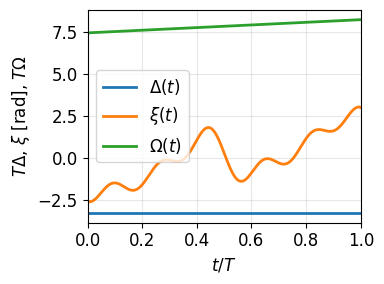

In [20]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin_profile
)
initial_params =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d*0.95,0.91540583*d*1.05])
plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

***Testing gate error for small variation of Rabi frequency during pulse***

In [24]:
d=19.16385937372734
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin_profile
)
initial_params =  (d, [-0.37987234 ], [0.43832597 , 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583,0.91540583*0.999 ])
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states)

Array(0.00027025, dtype=float64)

**Calculating robustness of amplitude-robust gate with gradient of Rabi frequency**

In [21]:
d=19.16385937372734
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
initial_params =  (1, [-0.37987234*d], [0.43832597*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin_profile
)
FRobustLin=[]
for i in range(len(Linlist)):
    initial_params=initial_params[0],initial_params[1],initial_params[2],[(1-0.5*Linlist[i])*0.91540583*d,(1+0.5*Linlist[i])*0.91540583*d]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FRobustLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FRobustLin

[0.029291400122982036,
 0.0073785706242415205,
 7.318811161560745e-07,
 0.007410672996252643,
 0.029322129473123182]

In [37]:
FRobustLin=[0.029291400122982036,
 0.0073785706242415205,
 7.318811161560745e-07,
 0.007410672996252643,
 0.029322129473123182]

**Robustness of time-optimal gate with gradient of Rabi frequency**

In [22]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab, rabi_ansatz=lin_profile
) 
d=7.6266
optimized_params =(1, [0.03126*d], [0.82, 0.664], [1*d])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
FTOLin=[]
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
for i in range(len(Linlist)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1-0.5*Linlist[i]),d*(1+0.5*Linlist[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTOLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FTOLin

[0.00431115686318484,
 0.001079063030581695,
 5.5350276473298266e-08,
 0.0010790633079461598,
 0.004311157436033053]

In [38]:
FTOLin=[0.00431115686318484,
 0.001079063030581695,
 5.5350276473298266e-08,
 0.0010790633079461598,
 0.004311157436033053]

**Robustness of Levine-Pichler gate with gradient of Rabi frequency**

In [23]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=lin_profile
) 
d=8.585308327286219
optimized_params=(1, [-0.37736613*d], [2.38073847], [d])
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
FLevineLin=[]
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
for i in range(len(Linlist)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1-0.5*Linlist[i]),d*(1+0.5*Linlist[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevineLin.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLevineLin

[0.00790112233142326,
 0.001979567981809538,
 7.85302844974467e-09,
 0.0019794854019540287,
 0.007901103551271493]

In [39]:
FLevineLin=[0.00790112233142326,
 0.001979567981809538,
 7.85302844974467e-09,
 0.0019794854019540287,
 0.007901103551271493]

In [40]:
FCounterLin=[0.00021901449486294577,
 5.1298131440336014e-05,
 7.550190417315861e-08,
 5.128306117940795e-05,
 0.0002190908356289878]

In [41]:
FOldRobustLin=[0.0030795726963303016,
 0.0008288938191242101,
 2.7268139199732033e-05,
 0.0006437426994012618,
 0.002645720340434532]

**This plot compares robustness of gate fidelities to gradient of Rabi frequency**

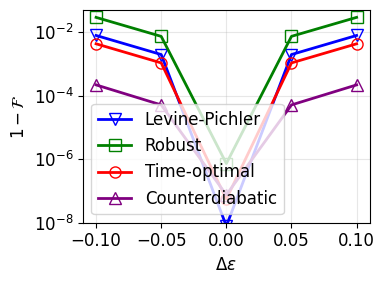

In [45]:
Linlist=[-0.1,-0.05, 0.0, 0.05, 0.1]
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(Linlist, FLevineLin, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)

# Plot the second series
ax.plot(Linlist, FRobustLin, label='Robust', color='green', marker='s', mfc='none', markersize=8)

# Plot the second series
ax.plot(Linlist, FTOLin, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)

# Plot the second series
ax.plot(Linlist, FCounterLin, label='Counterdiabatic', color='purple', marker='^', mfc='none', markersize=8)


# Plot the second series
#ax.plot(Linlist, FOldRobustLin, label='Initial robust', color='black', marker='D', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Delta\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-8,5e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('Robustness_lin_plot.svg', format='svg')

# Display the plot
plt.show()

In [ ]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateInd:

    def __init__(self, s: float,    Vnn: float):
        self._s = s
        self._Vnn = Vnn
 
    
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex),   jnp.array([1,0], dtype=complex),  jnp.array([1,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5],
                   [Omega* jnp.exp(1j * Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            s=self._s
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5*s],
                   [Omega* jnp.exp(1j * Xi)*s*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1r,r1,rr"""
            V=self._Vnn
            s=self._s
            return jnp.array(
                    [
                      [0, Omega*jnp.exp(-1j * Xi)*0.5, Omega*jnp.exp(-1j * Xi)*0.5*s, 0], 
                      [Omega*jnp.exp(1j * Xi)*0.5, Delta, 0, Omega* jnp.exp(-1j * Xi)*0.5*s], 
                      [Omega* jnp.exp(1j * Xi)*0.5*s, 0,  Delta, Omega* jnp.exp(-1j * Xi)*0.5], 
                      [0, Omega* jnp.exp(1j * Xi)*0.5*s, Omega*jnp.exp(1j * Xi)*0.5, 2.0*Delta + V]
                    ]       
                )
        return hamiltonian1, hamiltonian2, hamiltonian3

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2